# 1D Action-Angle Coordinates and Inverse Transformations

galpy supports one-dimensional action-angle coordinates through
`actionAngleVertical` and their inverse transformations through
`actionAngleVerticalInverse`. These are useful for studying vertical
oscillations in disk potentials or any general 1D potential.

For the special case of the **harmonic oscillator**, `actionAngleHarmonic`
and `actionAngleHarmonicInverse` provide exact analytical action-angle
coordinates and their inverse. These work like the other 1D classes
described below, but only require the oscillator frequency $\omega$.

In [1]:
from galpy.actionAngle import actionAngleHarmonic, actionAngleHarmonicInverse

aAH = actionAngleHarmonic(omega=1.0)
print("J =", aAH(1.0, 0.2))
print("(J, Omega) =", aAH.actionsFreqs(1.0, 0.2))
print("(J, Omega, angle) =", aAH.actionsFreqsAngles(1.0, 0.2))

J = 0.52
(J, Omega) = (0.52, np.float64(1.0))
(J, Omega, angle) = (0.52, np.float64(1.0), np.float64(1.373400766945016))


The inverse transformation recovers the original $(x, v_x)$:

In [2]:
aAHI = actionAngleHarmonicInverse(omega=1.0)
J, O, a = aAH.actionsFreqsAngles(1.0, 0.2)
print("(x, vx) =", aAHI(J, a))

(x, vx) = (np.float64(1.0), np.float64(0.19999999999999996))


For general (non-harmonic) 1D potentials, read on.

In [3]:
%matplotlib inline
import numpy
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## actionAngleVertical

`actionAngleVertical` computes one-dimensional action-angle coordinates
for vertical oscillations. We first need to extract a vertical potential
from a 3D potential using `toVerticalPotential`.

In [4]:
from galpy.potential import toVerticalPotential, MWPotential2014

vp = toVerticalPotential(MWPotential2014, 1.0)

This extracts the vertical potential at $R = 1$ (in natural units). Now
we set up the `actionAngleVertical` object:

In [5]:
from galpy.actionAngle import actionAngleVertical

aAV = actionAngleVertical(pot=vp)

### Computing actions, frequencies, and angles

The action-angle object can be called with `(x, vx)` to compute
the action $J$. The input is the vertical position and vertical velocity.

In [6]:
aAV(0.1, 0.1)

array([0.01231433])

To also get the frequency $\Omega$, use `actionsFreqs`:

In [7]:
aAV.actionsFreqs(0.1, 0.1)

(array([0.01231433]), array([1.72942467]))

And to get the angle as well, use `actionsFreqsAngles`:

In [8]:
aAV.actionsFreqsAngles(0.1, 0.1)

(array([0.01231433]), array([1.72942467]), array([0.9955371]))

### Action conservation along a 1D orbit

A key property of action variables is that they are conserved along an
orbit. Let's verify this by integrating a 1D orbit and computing the
action at each time step.

In [9]:
from galpy.orbit import Orbit

o = Orbit([0.1, 0.1])  # 1D orbit: (x, vx)
ts = numpy.linspace(0.0, 20.0, 1001)
o.integrate(ts, vp)

Now compute the action at each time step and verify conservation:

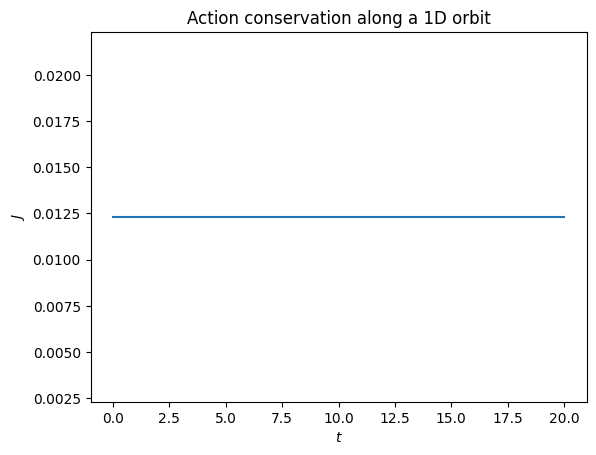

In [10]:
# Compute the action at each time step
actions = aAV(o.x(ts), o.vx(ts))
plt.plot(ts, actions)
plt.xlabel(r"$t$")
plt.ylabel(r"$J$")
plt.title("Action conservation along a 1D orbit")
plt.ylim(actions.mean() - 0.01, actions.mean() + 0.01);

The action is conserved to high precision along the orbit, as expected.

## actionAngleVerticalInverse

`actionAngleVerticalInverse` computes the reverse transformation: from
action-angle coordinates $(J, \theta)$ back to phase-space coordinates
$(x, v_x)$. This is useful for constructing tori in 1D potentials.

We demonstrate this with the `IsothermalDiskPotential`.

In [11]:
from galpy.potential import IsothermalDiskPotential

ip = IsothermalDiskPotential(amp=1.0, sigma=0.6)

Set up the inverse action-angle object. The `nta` parameter controls the
number of angle points used internally, and `Es` specifies the energies
for which to set up the transformation. Using `setup_interp=True` enables
interpolation between tori at different energies.

In [12]:
from galpy.actionAngle import actionAngleVerticalInverse

aAVI = actionAngleVerticalInverse(
    pot=ip,
    nta=512,
    Es=numpy.linspace(0.05, 1.0, 10),
    setup_interp=True,
)

### Evaluating the inverse transformation

We can evaluate the transformation to get $(x, v_x)$ from a given action
$J$ and an array of angles $\theta$.

In [13]:
angles = numpy.linspace(0, 2 * numpy.pi, 100)
x, vx = aAVI(0.1, angles)

### Plotting the torus

The resulting $(x, v_x)$ pairs trace out a torus (a closed curve in 1D
phase space).

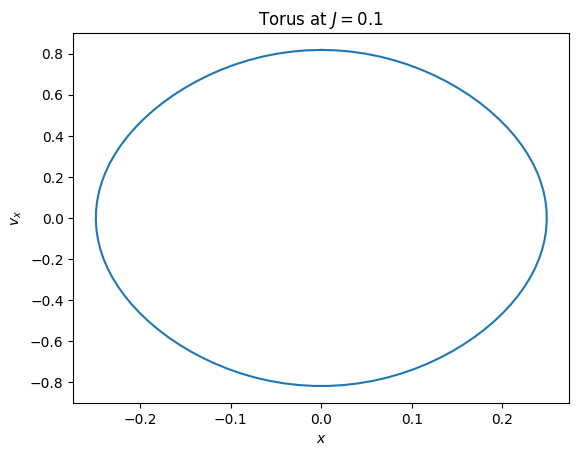

In [14]:
plt.plot(x, vx)
plt.xlabel(r"$x$")
plt.ylabel(r"$v_x$")
plt.title(r"Torus at $J = 0.1$");

You can also specify a torus using its energy instead by using the ``aA1Dinv.J`` method:

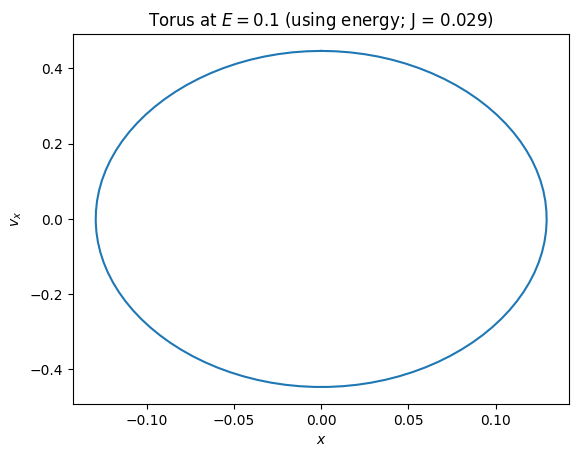

In [15]:
x, vx = aAVI(aAVI.J(0.1), angles)
plt.plot(x, vx)
plt.xlabel(r"$x$")
plt.ylabel(r"$v_x$")
plt.title(rf"Torus at $E = 0.1$ (using energy; J = {aAVI.J(0.1):.3f})");

We can also plot tori at multiple action values to visualize the
phase-space structure:

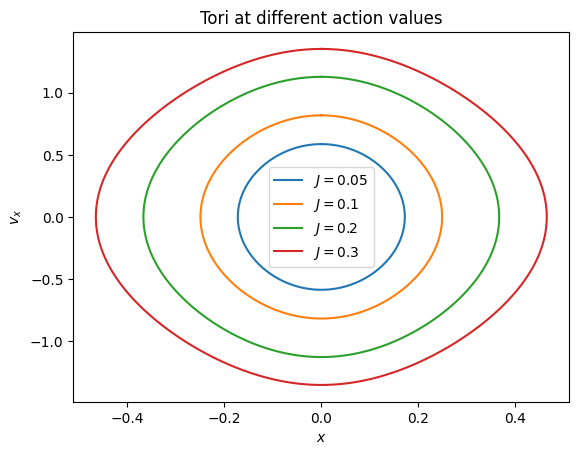

In [16]:
angles = numpy.linspace(0, 2 * numpy.pi, 200)
for J in [0.05, 0.1, 0.2, 0.3]:
    x, vx = aAVI(J, angles)
    plt.plot(x, vx, label=rf"$J = {J}$")
plt.xlabel(r"$x$")
plt.ylabel(r"$v_x$")
plt.legend()
plt.title("Tori at different action values");

The `setup_interp=True` option allows smooth interpolation between the
tori computed at the specified energies, enabling evaluation at arbitrary
action values within the range covered by those energies.